In [8]:
import pandas as pd
import os

In [9]:
os.listdir("data")

['MNCAATourneyCompactResults.csv',
 'MNCAATourneySlots.csv',
 'WNCAATourneyDetailedResults.csv',
 'WSecondaryTourneyTeams.csv',
 'MNCAATourneySeedRoundSlots.csv',
 'SampleSubmissionStage2.csv',
 'MTeamSpellings.csv',
 'MSeasons.csv',
 'MTeamCoaches.csv',
 'WNCAATourneySlots.csv',
 'MTeams.csv',
 'WSeasons.csv',
 'Cities.csv',
 'WTeams.csv',
 'MNCAATourneySeeds.csv',
 'MSecondaryTourneyCompactResults.csv',
 'MConferenceTourneyGames.csv',
 'WTeamConferences.csv',
 'WGameCities.csv',
 'WRegularSeasonDetailedResults.csv',
 'MRegularSeasonCompactResults.csv',
 'WNCAATourneySeeds.csv',
 'SampleSubmissionStage1.csv',
 'MSecondaryTourneyTeams.csv',
 'WSecondaryTourneyCompactResults.csv',
 'MGameCities.csv',
 'WNCAATourneyCompactResults.csv',
 'MRegularSeasonDetailedResults.csv',
 'Conferences.csv',
 'WRegularSeasonCompactResults.csv',
 'MTeamConferences.csv',
 'MMasseyOrdinals.csv',
 'MNCAATourneyDetailedResults.csv',
 'WTeamSpellings.csv',
 'WConferenceTourneyGames.csv']

## Team Statistics

In [10]:
rs = pd.read_csv("data/MRegularSeasonCompactResults.csv")
rs.head()
rs.shape
rs['Season'].unique()

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])

In [11]:
rs.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [12]:
rs.shape

(196823, 8)

In [13]:
# Winners
winners = rs[['Season','WTeamID','WScore','LScore']].copy()
winners.columns = ['Season','TeamID','Score','OppScore']
winners['Win'] = 1

# Losers
losers = rs[['Season','LTeamID','LScore','WScore']].copy()
losers.columns = ['Season','TeamID','Score','OppScore']
losers['Win'] = 0

# Combine
games = pd.concat([winners, losers])

games['ScoreDiff'] = games['Score'] - games['OppScore']

# Aggregate
team_stats = games.groupby(['Season','TeamID']).agg(
    GamesPlayed=('Win','count'),
    Wins=('Win','sum'),
    WinPct=('Win','mean'),
    AvgScoreDiff=('ScoreDiff','mean')
).reset_index()

team_stats.head()

,Season,TeamID,GamesPlayed,Wins,WinPct,AvgScoreDiff
0,1985,1102,24,5,0.208333,-5.791667
1,1985,1103,23,9,0.391304,-3.043478
2,1985,1104,30,21,0.700000,7.800000
3,1985,1106,24,10,0.416667,-3.791667
4,1985,1108,25,19,0.760000,7.960000


In [14]:
# total teams per season

teams_per_year = team_stats.groupby('Season').size()
print(teams_per_year)

Season
1985    282
1986    283
1987    290
1988    290
1989    293
1990    292
1991    295
1992    298
1993    298
1994    301
1995    302
1996    305
1997    305
1998    306
1999    310
2000    318
2001    318
2002    321
2003    327
2004    326
2005    330
2006    334
2007    336
2008    342
2009    347
2010    347
2011    345
2012    345
2013    347
2014    351
2015    351
2016    351
2017    351
2018    351
2019    353
2020    353
2021    347
2022    358
2023    363
2024    362
2025    364
2026    365
dtype: int64


In [15]:
# game played average

gp_avg = team_stats['GamesPlayed'].mean()
print(gp_avg)

28.622555078891878


In [16]:
# winpct distribution

team_stats['WinPct'].describe

<bound method NDFrame.describe of 0        0.208333
1        0.391304
2        0.700000
3        0.416667
4        0.760000
           ...   
13748    0.318182
13749    0.454545
13750    0.428571
13751    0.400000
13752    0.368421
Name: WinPct, Length: 13753, dtype: float64>

In [17]:
import matplotlib.pyplot as plt

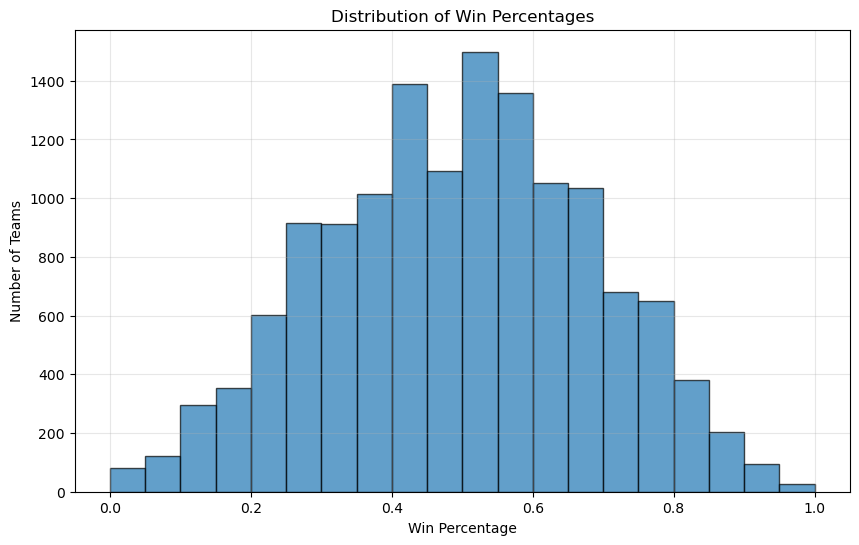

In [18]:
# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(team_stats['WinPct'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Win Percentage')
plt.ylabel('Number of Teams')
plt.title('Distribution of Win Percentages')
plt.grid(True, alpha=0.3)
plt.show()

## Tournament Data

In [20]:
tourney = pd.read_csv("data/MNCAATourneyCompactResults.csv")
tourney.head()
tourney.shape
tourney['Season'].unique()

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2021, 2022, 2023, 2024, 2025])

In [21]:
tourney.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [22]:
# compute games played
tourney.shape[0]

2585

In [23]:
# games per year
tourney.groupby("Season").size()

Season
1985    63
1986    63
1987    63
1988    63
1989    63
1990    63
1991    63
1992    63
1993    63
1994    63
1995    63
1996    63
1997    63
1998    63
1999    63
2000    63
2001    64
2002    64
2003    64
2004    64
2005    64
2006    64
2007    64
2008    64
2009    64
2010    64
2011    67
2012    67
2013    67
2014    67
2015    67
2016    67
2017    67
2018    67
2019    67
2021    66
2022    67
2023    67
2024    67
2025    67
dtype: int64

In [25]:
# Merge stats for winners
tourney = pd.read_csv("data/MNCAATourneyCompactResults.csv")

# Merge stats for both teams
tourney = tourney.merge(team_stats, 
                        left_on=['Season','WTeamID'],
                        right_on=['Season','TeamID'],
                        how='left')

tourney = tourney.merge(team_stats, 
                        left_on=['Season','LTeamID'],
                        right_on=['Season','TeamID'],
                        how='left',
                        suffixes=('_W','_L'))

# Now build ordered matchup
import numpy as np

tourney['Team1'] = np.minimum(tourney['WTeamID'], tourney['LTeamID'])
tourney['Team2'] = np.maximum(tourney['WTeamID'], tourney['LTeamID'])

tourney['Target'] = (tourney['Team1'] == tourney['WTeamID']).astype(int)

In [26]:
# First reduce to essential columns
tourney_simple = tourney[['Season','Team1','Team2','Target']].copy()

# Merge Team1 stats
tourney_simple = tourney_simple.merge(
    team_stats,
    left_on=['Season','Team1'],
    right_on=['Season','TeamID'],
    how='left'
).rename(columns={
    'WinPct':'WinPct1',
    'AvgScoreDiff':'ScoreDiff1',
    'GamesPlayed':'Games1'
}).drop(columns=['TeamID'])

# Merge Team2 stats
tourney_simple = tourney_simple.merge(
    team_stats,
    left_on=['Season','Team2'],
    right_on=['Season','TeamID'],
    how='left'
).rename(columns={
    'WinPct':'WinPct2',
    'AvgScoreDiff':'ScoreDiff2',
    'GamesPlayed':'Games2'
}).drop(columns=['TeamID'])

In [27]:
tourney_simple['WinPctDiff'] = tourney_simple['WinPct1'] - tourney_simple['WinPct2']
tourney_simple['ScoreDiffDiff'] = tourney_simple['ScoreDiff1'] - tourney_simple['ScoreDiff2']

In [28]:
massey = pd.read_csv("data/MMasseyOrdinals.csv")
massey.head()

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260


In [29]:
mteams =  pd.read_csv("data/MTeams.csv")
mteams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026
